## Clustering and Initialization

In [1]:
import sys
import os

sys.path.append(os.path.abspath("script"))

In [ ]:
from synthetic_data import generate_blobs
from plots import plot_synthetic_points, plot_kmeans_result, plot_results_kmeans_kmeanspp, plot_iterations, plot_strip, plot_best_worst_comparison
from kmeans import Kmeans, KmeansPlusPlus

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import load_digits, fetch_openml

#### Synthetic Datasets 

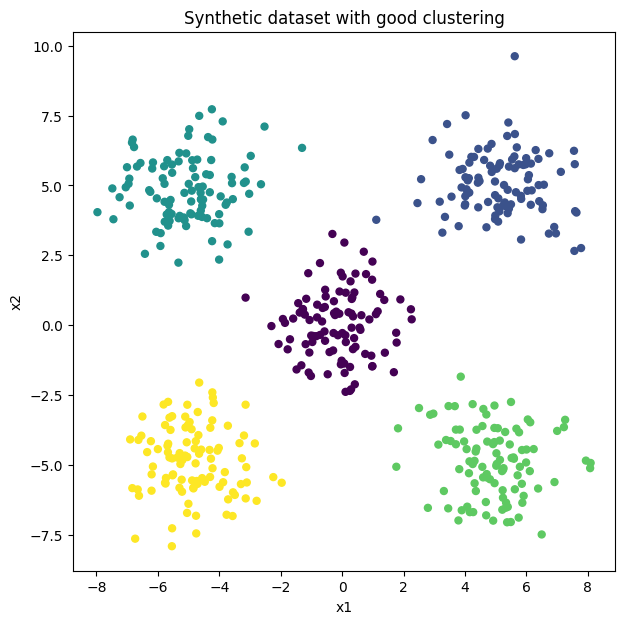

In [3]:
centers = [
    (0.0, 0.0),
    (5.0, 5.0),
    (-5.0, 5.0),
    (5.0, -5.0),
    (-5.0, -5.0)
]

n_samples = 500     # total number of points 
std = 1.2           # deviation standard
n_features = 2      # number of features
random_state = 42   # random seed

X, y = generate_blobs(centers=centers, n_samples=n_samples, std=std, n_features=n_features, random_state=random_state)

plot_synthetic_points(X, y)

#### Real-world datasets

In [4]:
# dataset digits from sklearn.datasets
data_digits = load_digits()
X_digits = data_digits.data
y_digits = data_digits.target

print("Shape X_digits =", X_digits.shape)
print("Shape y_digits =", y_digits.shape)

df = pd.DataFrame(X_digits)
df["label"] = y_digits

df

Shape X_digits = (1797, 64)
Shape y_digits = (1797,)


,0,1,2,3,4,5,6,7,8,9,...,55,56,57,58,59,60,61,62,63,label
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0,0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0,1
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0,2
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0,3
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1792,0.0,0.0,4.0,10.0,13.0,6.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,2.0,14.0,15.0,9.0,0.0,0.0,9
1793,0.0,0.0,6.0,16.0,13.0,11.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,6.0,16.0,14.0,6.0,0.0,0.0,0
1794,0.0,0.0,1.0,11.0,15.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,2.0,9.0,13.0,6.0,0.0,0.0,8
1795,0.0,0.0,2.0,10.0,7.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,5.0,12.0,16.0,12.0,0.0,0.0,9


In [5]:
df['label'].value_counts()

label
3    183
1    182
5    182
4    181
6    181
9    180
7    179
0    178
2    177
8    174
Name: count, dtype: int64

The MNIST dataset is a widely used benchmark in machine learning, consisting of 70000 grayscale images of handwritten digits (0–9), each represented as a 784-dimensional vector obtained by flattening 28 $\times$ 28 pixel images. 

In [6]:
X_mnist, y_mnist = fetch_openml(
    "mnist_784",
    version=1,
    return_X_y=True,
    as_frame=False
)

'''X_mnist = X_mnist.astype(np.float64) / 255.0
y_mnist = y_mnist.astype(int)

rng = np.random.default_rng(42)
idx = rng.choice(X_mnist.shape[0], size=10000, replace=False)

X_mnist = X_mnist[idx]
y_mnist = y_mnist[idx]'''

print("Shape X_MNIST =", X_mnist.shape)
print("Shape y_MNIST =", y_mnist.shape)

df_mnist = pd.DataFrame(X_mnist)
df_mnist["label"] = y_mnist

df_mnist

Shape X_MNIST = (70000, 784)
Shape y_MNIST = (70000,)


,0,1,2,3,4,5,6,7,8,9,...,775,776,777,778,779,780,781,782,783,label
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,5
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,4
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,2
69996,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,3
69997,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,4
69998,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,5


#### Run K-Means and K-means++

Multiple runs of Kmeans and Kmeans++ on synthetic dataset (mine).

In [9]:
# settings
n_clusters = 5
n_runs = 100
max_iter = 100
tol = 1e-4

inertias_kmeans = []
n_iters_kmeans = []
labels_kmeans = []
centroids_kmeans = [] 

inertias_kmeanspp = []
n_iters_kmeanspp = []
labels_kmeanspp = []
centroids_kmeanspp = []

for seed in range(n_runs):
    # kmeans
    model_kmeans = Kmeans(
        n_clusters=n_clusters,
        max_iter=max_iter,
        tol=tol,
        random_state=seed
    )

    model_kmeans.fit(X)

    inertias_kmeans.append(model_kmeans.inertia)
    n_iters_kmeans.append(model_kmeans.n_iter)
    labels_kmeans.append(model_kmeans.labels.copy())
    centroids_kmeans.append(model_kmeans.centroids.copy())

    # kmeans++
    model_kmeanspp = KmeansPlusPlus(
        n_clusters=n_clusters,
        max_iter=max_iter,
        tol=tol,
        random_state=seed
    )

    model_kmeanspp.fit(X)

    inertias_kmeanspp.append(model_kmeanspp.inertia)
    n_iters_kmeanspp.append(model_kmeanspp.n_iter)
    labels_kmeanspp.append(model_kmeanspp.labels.copy())
    centroids_kmeanspp.append(model_kmeanspp.centroids.copy())

inertias_kmeans = np.array(inertias_kmeans)
n_iters_kmeans = np.array(n_iters_kmeans)

inertias_kmeanspp = np.array(inertias_kmeanspp)
n_iters_kmeanspp = np.array(n_iters_kmeanspp)

Multiple runs of Kmeans and Kmeans++ on digits dataset.

In [23]:
# settings
n_clusters = 10
n_runs = 100
max_iter = 100
tol = 1e-4

inertias_kmeans_digits = []
n_iters_kmeans_digits = []
labels_kmeans_digits = []
centroids_kmeans_digits = [] 

inertias_kmeanspp_digits = []
n_iters_kmeanspp_digits = []
labels_kmeanspp_digits = []
centroids_kmeanspp_digits = []

for seed in range(n_runs):
    # kmeans
    model_kmeans_digits = Kmeans(
        n_clusters=n_clusters,
        max_iter=max_iter,
        tol=tol,
        random_state=seed
    )

    model_kmeans_digits.fit(X_digits)

    inertias_kmeans_digits.append(model_kmeans_digits.inertia)
    n_iters_kmeans_digits.append(model_kmeans_digits.n_iter)
    labels_kmeans_digits.append(model_kmeans_digits.labels.copy())
    centroids_kmeans_digits.append(model_kmeans_digits.centroids.copy())

    # kmeans++
    model_kmeanspp_digits = KmeansPlusPlus(
        n_clusters=n_clusters,
        max_iter=max_iter,
        tol=tol,
        random_state=seed
    )

    model_kmeanspp_digits.fit(X_digits)

    inertias_kmeanspp_digits.append(model_kmeanspp_digits.inertia)
    n_iters_kmeanspp_digits.append(model_kmeanspp_digits.n_iter)
    labels_kmeanspp_digits.append(model_kmeanspp_digits.labels.copy())
    centroids_kmeanspp_digits.append(model_kmeanspp_digits.centroids.copy())

inertias_kmeans_digits = np.array(inertias_kmeans_digits)
n_iters_kmeans_digits = np.array(n_iters_kmeans_digits)

inertias_kmeanspp_digits = np.array(inertias_kmeanspp_digits)
n_iters_kmeanspp_digits = np.array(n_iters_kmeanspp_digits)

Multiple runs of Kmeans and Kmeans++ on MNIST dataset.

In [10]:
#todo

#### Results K-Means and K-means++ on synthetic dataset (mine)

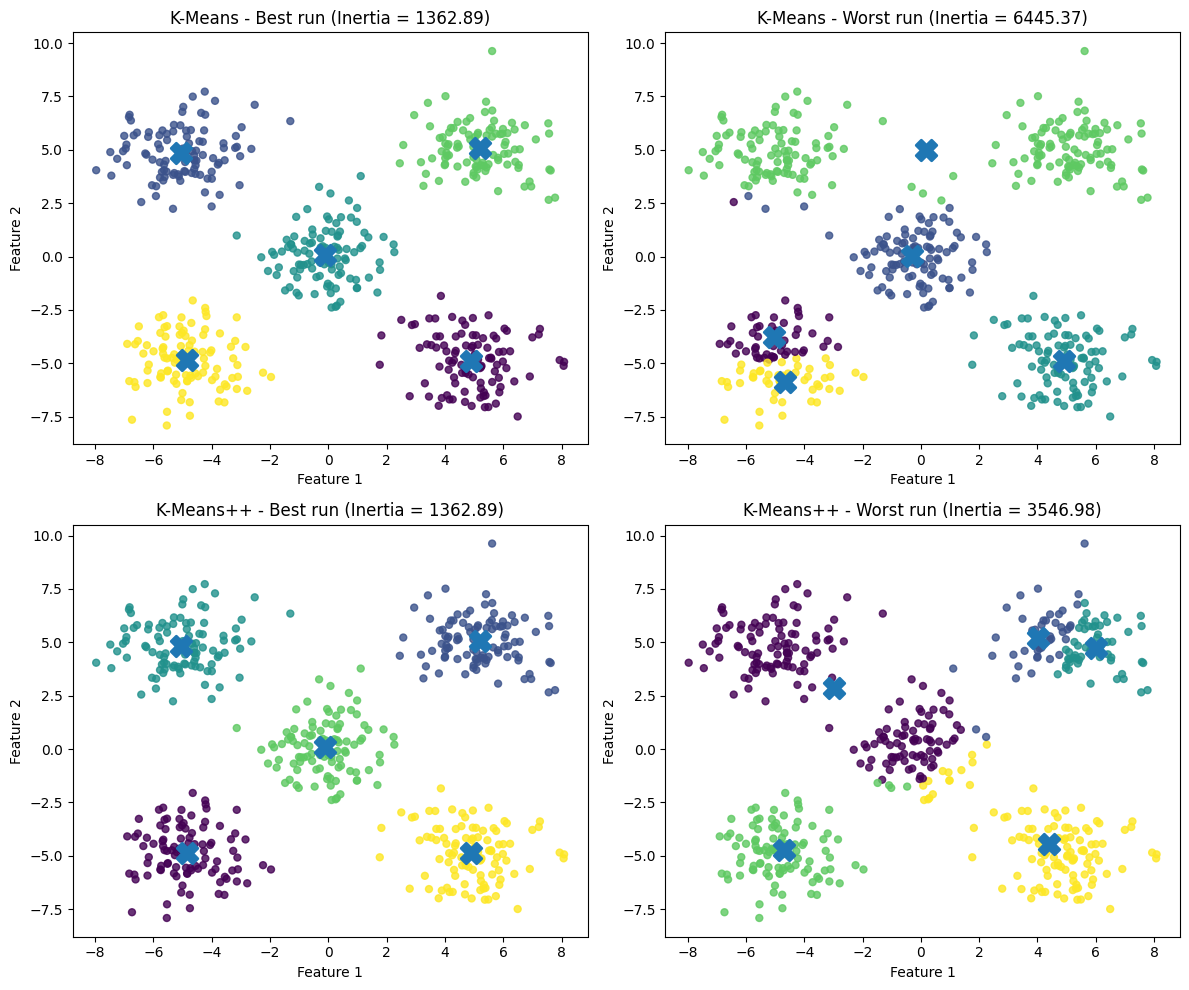

In [ ]:
plot_best_worst_comparison(
    X,
    inertias_kmeans,
    labels_kmeans,
    centroids_kmeans,
    inertias_kmeanspp,
    labels_kmeanspp,
    centroids_kmeanspp
)

In [ ]:
plot_results_kmeans_kmeanspp(X,
                             inertias_kmeans,
                             n_iters_kmeans,
                             inertias_kmeanspp,
                             n_iters_kmeanspp)

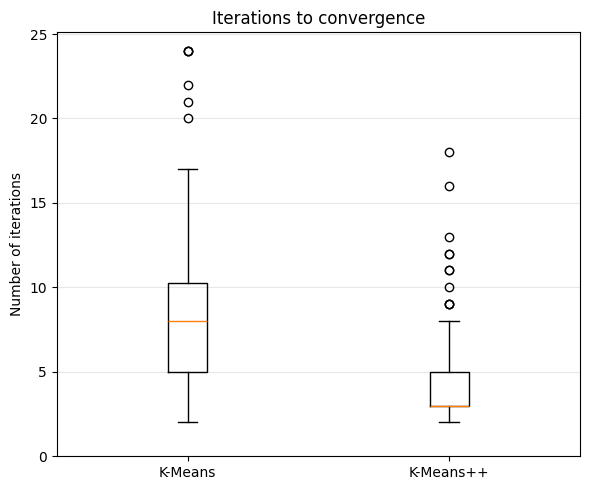

In [ ]:
plot_iterations(n_iters_kmeans, n_iters_kmeanspp)

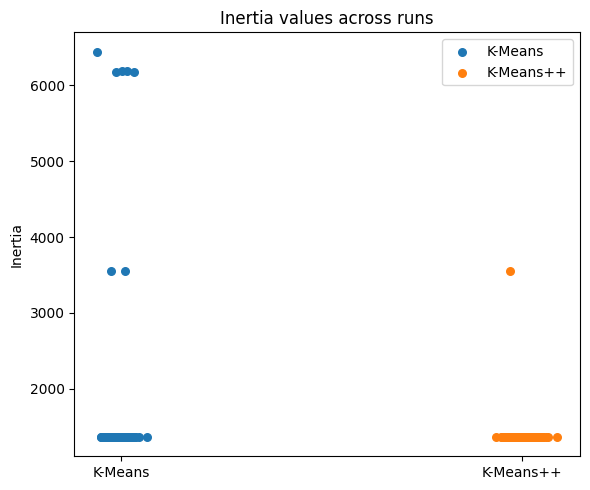

In [ ]:
plot_strip(inertias_kmeans, inertias_kmeanspp)

#### Results K-Means and K-means++ on digits dataset


K-Means
--------
Mean inertia    : 1186018.5204
Std inertia     : 23595.0103
Min inertia     : 1165144.5411
Max inertia     : 1270355.2554
Mean iterations : 21.09
Max iterations K-Means    : 53

K-Means++
-----------
Mean inertia    : 1186155.2723
Std inertia     : 23387.1509
Min inertia     : 1165162.0527
Max inertia     : 1267701.9755
Mean iterations : 20.19
Max iterations K-Means    : 53


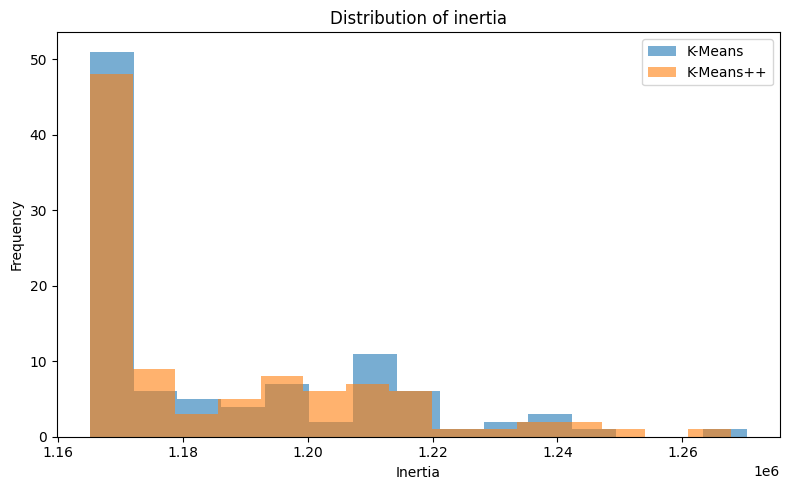

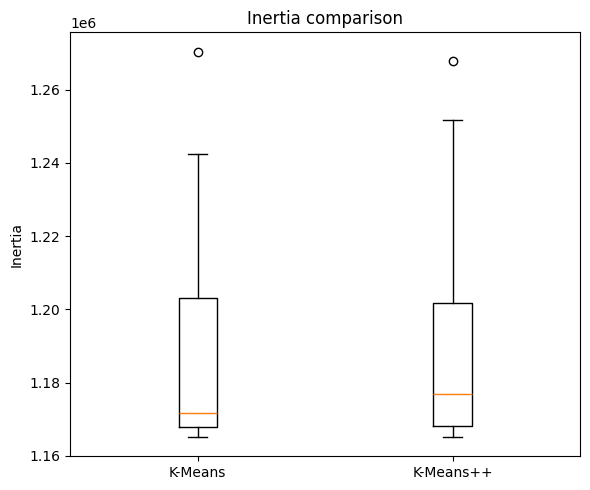

In [ ]:
plot_results_kmeans_kmeanspp(X_digits,
                             inertias_kmeans_digits,
                             n_iters_kmeans_digits,
                             inertias_kmeanspp_digits,
                             n_iters_kmeanspp_digits)

In [ ]:
plot_iterations(n_iters_kmeans_digits, n_iters_kmeanspp_digits)

In [ ]:
plot_strip(inertias_kmeans, inertias_kmeanspp)

#### Results K-Means and K-means++ on MNIST dataset    

In [13]:
#todo

#### Comparison with KMeans from scikit-learn library

In [26]:
# multiple runs of KMeans from scikit learn on digits dataset
inertias_sklearn = []
n_iters_sklearn = []
labels_sklearn = []
centroids_sklearn = []

inertias_sklearn_pp = []
n_iters_sklearn_pp = []
labels_sklearn_pp = []
centroids_sklearn_pp = []

# settings
n_clusters = 5
n_runs = 100
max_iter = 100
tol = 1e-4

for seed in range(n_runs):
    model_sklearn = KMeans(
        n_clusters=n_clusters,
        init="random",
        n_init=1,
        max_iter=max_iter,
        tol=tol,
        random_state=seed
    )

    model_sklearn.fit(X)

    inertias_sklearn.append(model_sklearn.inertia_)
    n_iters_sklearn.append(model_sklearn.n_iter_)
    labels_sklearn.append(model_sklearn.labels_.copy())
    centroids_sklearn.append(model_sklearn.cluster_centers_.copy())

    model_sklearn_pp = KMeans(
        n_clusters=n_clusters,
        init='k-means++',
        n_init=1,
        max_iter=max_iter,
        tol=tol,
        random_state=seed
    )

    model_sklearn_pp.fit(X)

    inertias_sklearn_pp.append(model_sklearn_pp.inertia_)
    n_iters_sklearn_pp.append(model_sklearn_pp.n_iter_)
    labels_sklearn_pp.append(model_sklearn_pp.labels_.copy())
    centroids_sklearn_pp.append(model_sklearn_pp.cluster_centers_.copy())

inertias_sklearn = np.array(inertias_sklearn)
n_iters_sklearn = np.array(n_iters_sklearn)

inertias_sklearn_pp = np.array(inertias_sklearn_pp)
n_iters_sklearn_pp = np.array(n_iters_sklearn_pp)

print("\nScikit-learn K-Means")
print("--------------------")
print(f"Mean inertia    : {np.mean(inertias_sklearn):.4f}")
print(f"Std inertia     : {np.std(inertias_sklearn):.4f}")
print(f"Min inertia     : {np.min(inertias_sklearn):.4f}")
print(f"Max inertia     : {np.max(inertias_sklearn):.4f}")
print(f"Mean iterations : {np.mean(n_iters_sklearn):.2f}")

print("\nScikit-learn K-Means++")
print("--------------------")
print(f"Mean inertia    : {np.mean(inertias_sklearn_pp):.4f}")
print(f"Std inertia     : {np.std(inertias_sklearn_pp):.4f}")
print(f"Min inertia     : {np.min(inertias_sklearn_pp):.4f}")
print(f"Max inertia     : {np.max(inertias_sklearn_pp):.4f}")
print(f"Mean iterations : {np.mean(n_iters_sklearn_pp):.2f}")


Scikit-learn K-Means
--------------------
Mean inertia    : 1665.9726
Std inertia     : 1129.0012
Min inertia     : 1362.8852
Max inertia     : 6182.0555
Mean iterations : 8.23

Scikit-learn K-Means++
--------------------
Mean inertia    : 1362.8852
Std inertia     : 0.0000
Min inertia     : 1362.8852
Max inertia     : 1362.8852
Mean iterations : 3.02


In [27]:
# multiple runs of KMeans from scikit learn on digits dataset
inertias_sklearn = []
n_iters_sklearn = []
labels_sklearn = []
centroids_sklearn = []

inertias_sklearn_pp = []
n_iters_sklearn_pp = []
labels_sklearn_pp = []
centroids_sklearn_pp = []

# settings
n_clusters = 10
n_runs = 100
max_iter = 100
tol = 1e-4

for seed in range(n_runs):
    model_sklearn = KMeans(
        n_clusters=n_clusters,
        init="random",
        n_init=1,
        max_iter=max_iter,
        tol=tol,
        random_state=seed
    )

    model_sklearn.fit(X_digits)

    inertias_sklearn.append(model_sklearn.inertia_)
    n_iters_sklearn.append(model_sklearn.n_iter_)
    labels_sklearn.append(model_sklearn.labels_.copy())
    centroids_sklearn.append(model_sklearn.cluster_centers_.copy())

    model_sklearn_pp = KMeans(
        n_clusters=n_clusters,
        init='k-means++',
        n_init=1,
        max_iter=max_iter,
        tol=tol,
        random_state=seed
    )

    model_sklearn_pp.fit(X_digits)

    inertias_sklearn_pp.append(model_sklearn_pp.inertia_)
    n_iters_sklearn_pp.append(model_sklearn_pp.n_iter_)
    labels_sklearn_pp.append(model_sklearn_pp.labels_.copy())
    centroids_sklearn_pp.append(model_sklearn_pp.cluster_centers_.copy())

inertias_sklearn = np.array(inertias_sklearn)
n_iters_sklearn = np.array(n_iters_sklearn)

inertias_sklearn_pp = np.array(inertias_sklearn_pp)
n_iters_sklearn_pp = np.array(n_iters_sklearn_pp)

print("\nScikit-learn K-Means")
print("--------------------")
print(f"Mean inertia    : {np.mean(inertias_sklearn):.4f}")
print(f"Std inertia     : {np.std(inertias_sklearn):.4f}")
print(f"Min inertia     : {np.min(inertias_sklearn):.4f}")
print(f"Max inertia     : {np.max(inertias_sklearn):.4f}")
print(f"Mean iterations : {np.mean(n_iters_sklearn):.2f}")

print("\nScikit-learn K-Means++")
print("--------------------")
print(f"Mean inertia    : {np.mean(inertias_sklearn_pp):.4f}")
print(f"Std inertia     : {np.std(inertias_sklearn_pp):.4f}")
print(f"Min inertia     : {np.min(inertias_sklearn_pp):.4f}")
print(f"Max inertia     : {np.max(inertias_sklearn_pp):.4f}")
print(f"Mean iterations : {np.mean(n_iters_sklearn_pp):.2f}")


Scikit-learn K-Means
--------------------
Mean inertia    : 1184130.2477
Std inertia     : 19863.8052
Min inertia     : 1165180.6246
Max inertia     : 1240657.8699
Mean iterations : 22.08

Scikit-learn K-Means++
--------------------
Mean inertia    : 1178966.6522
Std inertia     : 15749.7529
Min inertia     : 1165144.2336
Max inertia     : 1220546.4947
Mean iterations : 19.86


#### Overlapping clusters